In [1]:
!pip install kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "bhanupratapbiswas/customer-behavior-analysis"
)

print("Path to dataset files:", path)

100%|██████████| 9.94M/9.94M [00:00<00:00, 44.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bhanupratapbiswas/customer-behavior-analysis/versions/1


In [3]:
import os

os.listdir(path)

['ecommerce_customer_data_custom_ratios.csv',
 'ecommerce_customer_data_large.csv']

In [4]:
import pandas as pd

df = pd.read_csv(path + "/ecommerce_customer_data_large.csv")

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [6]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47382
Customer Name,0


In [7]:
df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print("Cleaning completed")

Cleaning completed


In [8]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,202618.000000,202618.000000,202618.000000,202618.000000,202618.000000,202618.000000,202618.000000,202618.000000
mean,25020.140234,254.899066,3.008420,2725.817662,43.817923,0.500824,43.817923,0.201088
std,14412.388674,141.720425,1.414339,1442.268491,15.356067,0.500001,15.356067,0.400815
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12599.250000,133.000000,2.000000,1478.000000,30.000000,0.000000,30.000000,0.000000
50%,25018.000000,255.000000,3.000000,2727.000000,44.000000,1.000000,44.000000,0.000000
75%,37444.000000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.000000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [9]:
print("MEAN")
print(df.mean(numeric_only=True))

print("\nMEDIAN")
print(df.median(numeric_only=True))

print("\nMODE")
print(df.mode().iloc[0])

MEAN
Customer ID              25020.140234
Product Price              254.899066
Quantity                     3.008420
Total Purchase Amount     2725.817662
Customer Age                43.817923
Returns                      0.500824
Age                         43.817923
Churn                        0.201088
dtype: float64

MEDIAN
Customer ID              25018.0
Product Price              255.0
Quantity                     3.0
Total Purchase Amount     2727.0
Customer Age                44.0
Returns                      1.0
Age                         44.0
Churn                        0.0
dtype: float64

MODE
Customer ID                          13805.0
Purchase Date            2020-01-06 22:26:24
Product Category                    Clothing
Product Price                          290.0
Quantity                                 4.0
Total Purchase Amount                 2174.0
Payment Method                        PayPal
Customer Age                            47.0
Returns                

In [10]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [11]:
df['Price_Per_Item'] = (
    df['Total Purchase Amount'] / df['Quantity']
)

df[['Total Purchase Amount', 'Quantity', 'Price_Per_Item']].head()

,Total Purchase Amount,Quantity,Price_Per_Item
0,2427,1,2427.000000
1,2448,3,816.000000
2,2345,1,2345.000000
3,937,3,312.333333
4,2598,4,649.500000


In [12]:
df['Customer_Segment'] = pd.qcut(
    df['Total Purchase Amount'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

df[['Total Purchase Amount', 'Customer_Segment']].head()


,Total Purchase Amount,Customer_Segment
0,2427,Medium Value
1,2448,Medium Value
2,2345,Medium Value
3,937,Low Value
4,2598,Medium Value


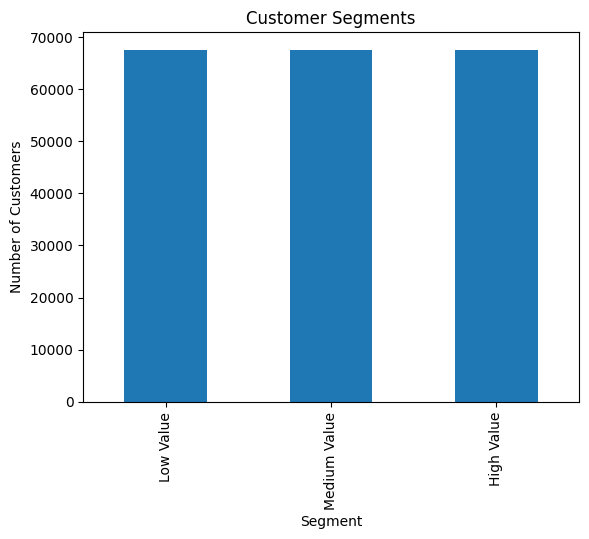

In [13]:
import matplotlib.pyplot as plt

df['Customer_Segment'].value_counts().plot(kind='bar')

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

100%|██████████| 9.94M/9.94M [00:00<00:00, 139MB/s]

Extracting files...


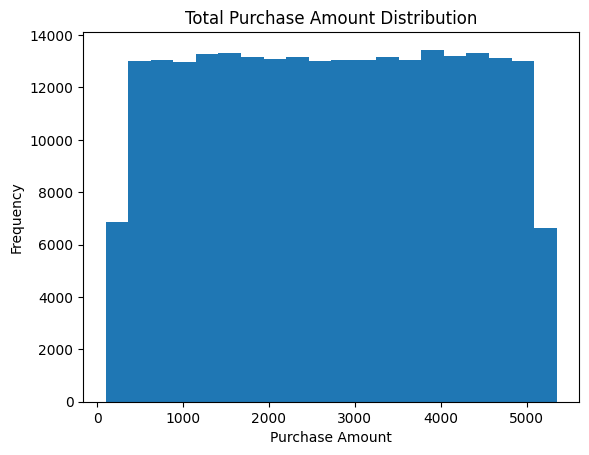

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

# Download dataset again
path = kagglehub.dataset_download(
    "bhanupratapbiswas/customer-behavior-analysis"
)

# Load dataset
df = pd.read_csv(path + "/ecommerce_customer_data_large.csv")

# Histogram
plt.hist(df['Total Purchase Amount'], bins=20)

plt.title("Total Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")

plt.show()

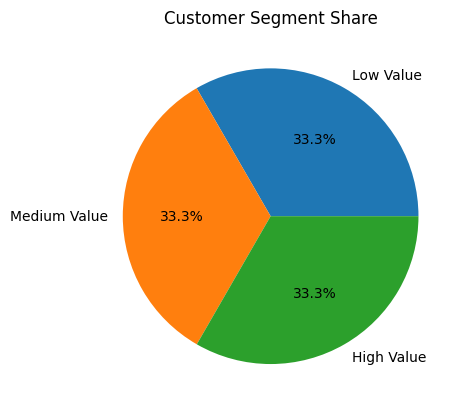

In [5]:
df['Customer_Segment'] = pd.qcut(
    df['Total Purchase Amount'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

df['Customer_Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Customer Segment Share")
plt.ylabel("")

plt.show()

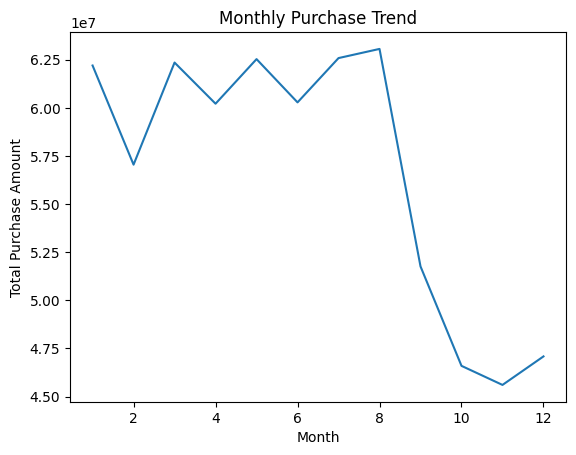

In [6]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

monthly_sales = df.groupby(
    df['Purchase Date'].dt.month
)['Total Purchase Amount'].sum()

monthly_sales.plot(kind='line')

plt.title("Monthly Purchase Trend")
plt.xlabel("Month")
plt.ylabel("Total Purchase Amount")

plt.show()

# Key Insights and Recommendations

1. High-value customers contribute significantly to the overall purchase amount. Alfido Tech should focus on retaining these customers through loyalty programs and personalized offers.

2. Purchase trends vary across months, indicating seasonal buying behavior. Marketing campaigns should be intensified during high-sales periods to maximize revenue.

3. A large portion of customers belong to the medium-value segment. Targeted promotions and bundle offers can help convert them into high-value customers.

4. Customer segmentation helps identify purchasing patterns effectively. Alfido Tech can use segmentation to create personalized marketing strategies.

5. Monitoring purchase behavior and returns can help improve customer satisfaction and reduce churn rates.

# Project Summary

In this project, customer behavior data was analyzed using Python in Google Colab. The dataset was cleaned by removing missing values and duplicates. Feature engineering was performed by creating additional useful metrics such as price per item. Customers were segmented into low, medium, and high-value groups based on purchase amounts.

Several visualizations including bar charts, histograms, pie charts, and line charts were created to understand customer purchasing behavior and trends. The analysis provided useful business insights and recommendations that can help Alfido Tech improve customer retention, marketing strategies, and sales performance.